<a href="https://colab.research.google.com/github/lucaslopez411-bot/Proyectos-Personales-Data-Science/blob/main/Proyecto_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de sentimientos en tweets en español con NLP y PyTorch

Proyecto de **Procesamiento de Lenguaje Natural (NLP)** orientado a clasificar tweets en seis categorías de sentimiento mediante un pipeline que combina limpieza de texto, lematización, representación **TF-IDF** y una red neuronal implementada en **PyTorch**.

## Objetivo

Construir y evaluar un modelo multiclase capaz de identificar el sentimiento predominante de un tweet. El proyecto recorre el flujo completo de trabajo: exploración, preprocesamiento, representación vectorial, entrenamiento, validación y evaluación.

**Tecnologías:** Python · pandas · NLTK · spaCy · scikit-learn · PyTorch · Plotly · Matplotlib


In [12]:
!python -m spacy download es_core_news_sm

import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import nltk
import spacy
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

for recurso in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(recurso, quiet=True)

RANDOM_STATE = 42


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 74.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Carga y control de calidad del dataset

El dataset contiene tweets en español junto con variables de emoción y sentimiento. Primero se revisa su estructura y se eliminan registros duplicados antes del análisis.


In [13]:
df = pd.read_csv("https://raw.githubusercontent.com/lucaslopez411-bot/Proyectos-Personales-Data-Science/refs/heads/main/Datasets/sentiment_analysis_dataset.csv")

In [14]:
# Resumen inicial y limpieza
obs_iniciales = len(df)
nulos = df.isnull().sum().sum()
duplicados_detectados = df.duplicated().sum()

df = df.drop_duplicates().copy()

obs_finales = len(df)

tabla_dataset = pd.DataFrame({
    "Característica": [
        "Observaciones iniciales",
        "Valores nulos detectados",
        "Registros duplicados detectados",
        "Observaciones finales",
        "Variables"
    ],
    "Valor": [
        obs_iniciales,
        nulos,
        duplicados_detectados,
        obs_finales,
        df.shape[1]
    ]
})

tabla_dataset


,Característica,Valor
0,Observaciones iniciales,2590
1,Valores nulos detectados,0
2,Registros duplicados detectados,115
3,Observaciones finales,2475
4,Variables,5


## 3. Análisis exploratorio de datos

Se analiza el balance de las clases y la longitud de los tweets. Esto permite identificar posibles desbalances y comprender mejor la estructura del corpus antes del modelado.


In [15]:
import plotly.express as px

conteo = (
    df["sentiment"]
    .value_counts()
    .reset_index()
)

conteo.columns = ["Sentimiento","Cantidad"]

fig = px.bar(
    conteo,
    x="Sentimiento",
    y="Cantidad",
    color="Sentimiento",
    text="Cantidad",
    title="Distribución de las clases (Sentimientos)"
)

fig.update_traces(textposition="outside")

fig.show()

In [16]:
emotion_counts = (
    df["emotion"]
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
)

emotion_counts.columns = ["Emoción", "Cantidad"]

fig = px.bar(
    emotion_counts,
    x="Emoción",
    y="Cantidad",
    color="Emoción",
    text="Cantidad",
    title="Distribución de las emociones"
)

fig.update_traces(
    textposition="outside",
    showlegend=False
)

fig.update_layout(
    xaxis_title="Emoción",
    yaxis_title="Cantidad",
    xaxis_tickangle=-45,
    height=600,
    title_x=0.5
)

fig.show()

In [17]:
df["n_palabras"] = df["text"].astype(str).str.split().str.len()
p99 = df["n_palabras"].quantile(0.99)

fig = px.histogram(
    df[df["n_palabras"] <= p99],
    x="n_palabras",
    nbins=30,
    title="Distribución de la longitud de los tweets"
)

fig.update_layout(
    width=900,
    height=550,
    title_x=0.5,
    xaxis_title="Cantidad de palabras",
    yaxis_title="Frecuencia"
)

fig.show()


## 4. Preprocesamiento NLP

El texto se normaliza mediante expresiones regulares: conversión a minúsculas, eliminación de URLs, menciones, números y caracteres especiales. Luego se comparan dos enfoques de lematización:

- **NLTK**, utilizado como referencia.
- **spaCy**, elegido para construir el texto final empleado por el modelo.

La comparación permite documentar la decisión metodológica en lugar de aplicar una única herramienta sin evaluación previa.


In [18]:
import re

def limpiar_texto_regex(texto):
    texto = str(texto).lower()

    # Eliminar URLs
    texto = re.sub(r"http\S+|www\S+|https\S+", "", texto)

    # Eliminar menciones
    texto = re.sub(r"@\w+", "", texto)

    # Quitar el símbolo # pero conservar la palabra del hashtag
    texto = re.sub(r"#", "", texto)

    # Eliminar números
    texto = re.sub(r"\d+", "", texto)

    # Eliminar caracteres especiales, conservando letras en español y espacios
    texto = re.sub(r"[^a-záéíóúñü\s]", "", texto)

    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

In [19]:
df["text_clean"] = df["text"].apply(limpiar_texto_regex)

In [20]:
stop_words = set(stopwords.words("spanish"))
lemmatizer = WordNetLemmatizer()

def tokenizar_nltk(texto):
    return word_tokenize(texto, language="spanish")

def lematizar_nltk(texto):
    tokens = tokenizar_nltk(texto)
    lemas = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words
    ]
    return " ".join(lemas)

df["tokens_nltk"] = df["text_clean"].apply(tokenizar_nltk)
df["lemma_nltk"] = df["text_clean"].apply(lematizar_nltk)


In [21]:
nlp = spacy.load("es_core_news_sm")

def lematizar_spacy(texto):
    doc = nlp(texto)
    lemas = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.lemma_.strip() != ""
    ]
    return " ".join(lemas)

df["lemma_spacy"] = df["text_clean"].apply(lematizar_spacy)


In [22]:
extra_stopwords = {
    "q", "x", "pa", "xd", "rt", "https", "http",
    "él", "ella", "ello", "ellos", "ellas",
    "ser", "haber", "estar",
    "yo", "tú", "vos", "usted",
    "aqui", "ahí", "alli",
    "si", "no"
}

def limpiar_tokens_finales(texto):
    tokens = str(texto).split()
    tokens_filtrados = [
        palabra for palabra in tokens
        if len(palabra) > 2 and palabra not in extra_stopwords
    ]
    return " ".join(tokens_filtrados)

df["text_final_nltk"] = df["lemma_nltk"].apply(limpiar_tokens_finales)
df["text_final_spacy"] = df["lemma_spacy"].apply(limpiar_tokens_finales)

df[["text", "text_clean", "lemma_nltk", "lemma_spacy", "text_final_spacy"]].sample(
    5, random_state=RANDOM_STATE
)


,text,text_clean,lemma_nltk,lemma_spacy,text_final_spacy
902,"""En el teatro silencioso de la existencia, las...",en el teatro silencioso de la existencia las l...,teatro silencioso existencia lágrimas ensayan ...,teatro silencioso existencia lágrima ensair da...,teatro silencioso existencia lágrima ensair da...
2136,"Lenia Batres, flamante Ministro de la Suprema ...",lenia batres flamante ministro de la suprema c...,lenia batres flamante ministro suprema corte j...,lenia batr flamante ministro suprema corte jus...,lenia batr flamante ministro suprema corte jus...
991,cómo es posible que haya rechazado una farra e...,cómo es posible que haya rechazado una farra e...,cómo posible rechazado farra pueblo desconozco,rechazar farra pueblo desconocer,rechazar farra pueblo desconocer
1712,Y yo confiado que era por ahi...,y yo confiado que era por ahi,confiado ahi,confiado,confiado
1809,Niño Palstino es el nuevo David y El vehículo ...,niño palstino es el nuevo david y el vehículo ...,niño palstino nuevo david vehículo blindado si...,niño palstino david vehículo blindado sionista...,niño palstino david vehículo blindado sionista...


### Palabras frecuentes después del preprocesamiento

La frecuencia posterior a la limpieza permite comprobar visualmente que el corpus final conserva términos informativos y reduce ruido lingüístico.


In [23]:
from collections import Counter
import pandas as pd
import plotly.express as px

texto = " ".join(df["text_final_spacy"])

contador = Counter(texto.split())

top10 = contador.most_common(10)

df_top10 = pd.DataFrame(
    top10,
    columns=["Palabra", "Frecuencia"]
)

fig = px.bar(
    df_top10,
    x="Frecuencia",
    y="Palabra",
    orientation="h",
    text="Frecuencia",
    title="10 palabras más frecuentes tras la limpieza y lematización"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,

    width=900,
    height=900,

    xaxis_title="Frecuencia",
    yaxis_title="",

    font=dict(size=16),

    title_font=dict(size=22),

    margin=dict(l=180, r=40, t=80, b=50),

    yaxis=dict(
        autorange="reversed",
        tickfont=dict(size=16)
    ),

    xaxis=dict(
        tickfont=dict(size=15)
    )
)

fig.show()

## 5. Preparación de los datos y representación TF-IDF

La variable objetivo se codifica numéricamente y el dataset se divide de forma estratificada en **70% entrenamiento, 15% validación y 15% prueba**.

El vectorizador TF-IDF se ajusta **exclusivamente con el conjunto de entrenamiento**. Validación y prueba utilizan únicamente `transform`, evitando incorporar información de esos conjuntos durante el ajuste de la representación.


In [24]:
X_text = df["text_final_spacy"]
y = df["sentiment"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases:", list(label_encoder.classes_))


Clases: ['joyful', 'mad', 'peaceful', 'powerful', 'sad', 'scared']


In [25]:
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text,
    y_encoded,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train: {len(X_train_text)} | Validation: {len(X_val_text)} | Test: {len(X_test_text)}")


Train: 1732 | Validation: 371 | Test: 372


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90
)

X_train = tfidf.fit_transform(X_train_text)
X_val = tfidf.transform(X_val_text)
X_test = tfidf.transform(X_test_text)

In [27]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1732, 3528)
X_val: (371, 3528)
X_test: (372, 3528)


## 6. Conversión a tensores y DataLoaders

Los vectores TF-IDF se convierten a tensores para entrenar la red neuronal en PyTorch. Los `DataLoader` permiten trabajar por lotes durante entrenamiento, validación y prueba.


In [28]:
X_train_array = X_train.toarray()
X_val_array = X_val.toarray()
X_test_array = X_test.toarray()

print(type(X_train_array))
print(X_train_array.shape)

<class 'numpy.ndarray'>
(1732, 3528)


In [29]:
import torch

X_train_tensor = torch.tensor(X_train_array, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_array, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_array, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [30]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 7. Modelo neuronal

Se utiliza una red feed-forward con dos capas ocultas. Cada bloque incorpora **Batch Normalization**, activación **ReLU** y **Dropout (0.5)** para favorecer la estabilidad del entrenamiento y reducir el sobreajuste.


In [31]:
import torch.nn as nn

class TextClassifier(nn.Module):

    def __init__(self, input_dim, num_classes):
        super(TextClassifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [32]:
input_dim = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)

print("Dimensión de entrada:", input_dim)
print("Cantidad de clases:", num_classes)

Dimensión de entrada: 3528
Cantidad de clases: 6


In [33]:
model = TextClassifier(input_dim=input_dim, num_classes=num_classes)

model

TextClassifier(
  (network): Sequential(
    (0): Linear(in_features=3528, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [34]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Entrenamiento y Early Stopping

El modelo se optimiza con **Adam** y `CrossEntropyLoss`. Se establece un máximo de 50 épocas y **Early Stopping** con paciencia de 5 épocas, conservando el estado con menor pérdida de validación.


In [35]:
num_epochs = 50
patience = 5

best_val_loss = float("inf")
counter = 0
best_model_state = None

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [36]:
for epoch in range(num_epochs):

    # ==========================
    # ENTRENAMIENTO
    # ==========================
    model.train()

    running_train_loss = 0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += y_batch.size(0)

        correct_train += (predicted == y_batch).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_acc = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ==========================
    # VALIDACIÓN
    # ==========================
    model.eval()

    running_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total_val += y_batch.size(0)

            correct_val += (predicted == y_batch).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_acc = correct_val / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Época {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # ==========================
    # EARLY STOPPING
    # ==========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()

    else:

        counter += 1

        if counter >= patience:

            print(f"\nEarly Stopping activado en la época {epoch+1}")

            break

model.load_state_dict(best_model_state)

Época 01 | Train Loss: 1.7911 | Train Acc: 0.2258 | Val Loss: 1.7707 | Val Acc: 0.2183
Época 02 | Train Loss: 1.3609 | Train Acc: 0.5104 | Val Loss: 1.6460 | Val Acc: 0.4501
Época 03 | Train Loss: 0.9814 | Train Acc: 0.7396 | Val Loss: 1.2589 | Val Acc: 0.5930
Época 04 | Train Loss: 0.6442 | Train Acc: 0.8557 | Val Loss: 1.1197 | Val Acc: 0.6388
Época 05 | Train Loss: 0.5263 | Train Acc: 0.9007 | Val Loss: 1.0990 | Val Acc: 0.6253
Época 06 | Train Loss: 0.3542 | Train Acc: 0.9244 | Val Loss: 1.1087 | Val Acc: 0.6307
Época 07 | Train Loss: 0.3449 | Train Acc: 0.9226 | Val Loss: 1.1330 | Val Acc: 0.6199
Época 08 | Train Loss: 0.2687 | Train Acc: 0.9330 | Val Loss: 1.1695 | Val Acc: 0.6442
Época 09 | Train Loss: 0.2471 | Train Acc: 0.9330 | Val Loss: 1.1929 | Val Acc: 0.6307
Época 10 | Train Loss: 0.2370 | Train Acc: 0.9307 | Val Loss: 1.2128 | Val Acc: 0.6442

Early Stopping activado en la época 10


<All keys matched successfully>

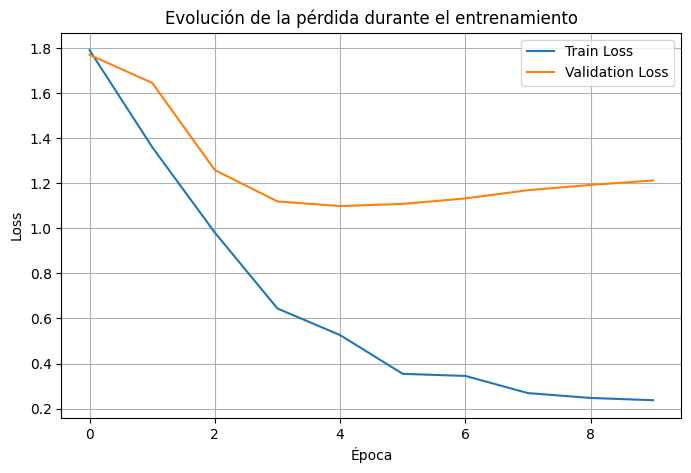

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

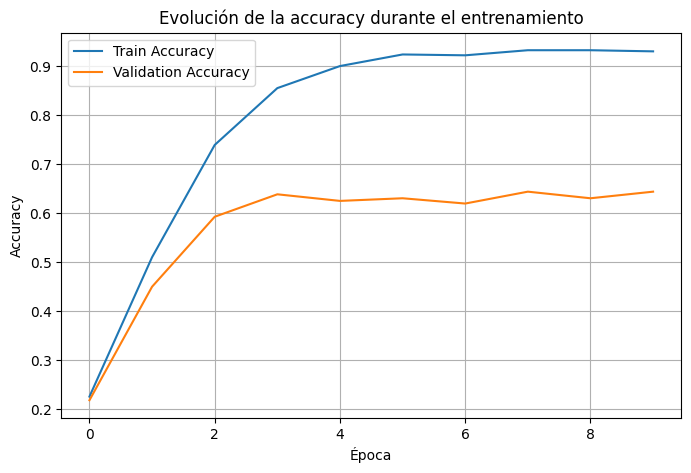

In [38]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("Evolución de la accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
tabla_entrenamiento = pd.DataFrame({
    "Parámetro": [
        "Optimizador",
        "Función de pérdida",
        "Batch Size",
        "Épocas máximas",
        "Early Stopping",
        "Paciencia",
        "Dropout",
        "Batch Normalization"
    ],
    "Valor": [
        "Adam",
        "CrossEntropyLoss",
        64,
        num_epochs,
        "Sí",
        5,
        0.5,
        "Sí"
    ]
})

tabla_entrenamiento

,Parámetro,Valor
0,Optimizador,Adam
1,Función de pérdida,CrossEntropyLoss
2,Batch Size,64
3,Épocas máximas,50
4,Early Stopping,Sí
5,Paciencia,5
6,Dropout,0.5
7,Batch Normalization,Sí


## 9. Evaluación sobre el conjunto de prueba

La evaluación final se realiza sobre datos no utilizados para entrenar ni seleccionar el modelo. Se reportan accuracy, precision, recall y F1-score por clase, junto con la matriz de confusión.


In [40]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.eval()

predicciones = []
reales = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        predicciones.extend(predicted.numpy())
        reales.extend(y_batch.numpy())

In [41]:
accuracy = accuracy_score(reales, predicciones)

print(f"Accuracy Test: {accuracy:.4f}")

Accuracy Test: 0.6398


In [42]:
# Obtener el classification report como diccionario
reporte = classification_report(
    reales,
    predicciones,
    target_names=label_encoder.classes_,
    output_dict=True
)

# Convertir a DataFrame
tabla_8 = pd.DataFrame(reporte).transpose()

# Redondear a 2 decimales
tabla_8 = tabla_8.round(2)

tabla_8

,precision,recall,f1-score,support
joyful,0.60,0.47,0.53,51.00
mad,0.70,0.78,0.74,80.00
peaceful,0.66,0.62,0.64,94.00
powerful,0.57,0.61,0.59,62.00
sad,0.68,0.69,0.69,49.00
scared,0.56,0.61,0.59,36.00
accuracy,0.64,0.64,0.64,0.64
macro avg,0.63,0.63,0.63,372.00
weighted avg,0.64,0.64,0.64,372.00


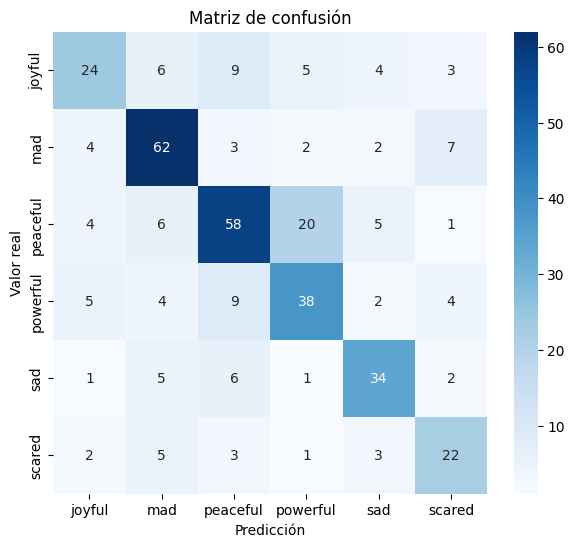

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(reales, predicciones)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")

plt.show()

## 10. Conclusiones

El pipeline permite abordar un problema de clasificación multiclase de sentimientos en español combinando técnicas clásicas de NLP con una red neuronal en PyTorch.

El modelo alcanza aproximadamente **64,5% de accuracy en test**. Más que interpretar esta métrica de forma aislada, el proyecto permite observar diferencias de desempeño entre clases mediante precision, recall, F1-score y la matriz de confusión.

### Principales aprendizajes

- La limpieza y normalización del texto son etapas determinantes en un pipeline de NLP.
- La comparación entre NLTK y spaCy permite justificar la estrategia de lematización utilizada.
- Ajustar TF-IDF únicamente sobre entrenamiento evita *data leakage* hacia validación y test.
- El uso de validación y Early Stopping permite controlar mejor el sobreajuste.
- En clasificación multiclase conviene analizar métricas por clase además de la accuracy global.

### Posibles mejoras

Como extensiones futuras podrían evaluarse modelos lineales como baseline, ajuste de hiperparámetros, técnicas específicas para el desbalance entre clases, embeddings preentrenados y arquitecturas basadas en Transformers para español.
